In [1]:
import os, glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DATA_ROOT = r"C:\Users\Mateo\.cache\kagglehub\datasets\borismarjanovic\price-volume-data-for-all-us-stocks-etfs\versions\3"
STOCKS_DIR = os.path.join(DATA_ROOT, "Stocks")

files = os.listdir(STOCKS_DIR)
stock_files = [os.path.join(STOCKS_DIR, f) for f in files if f.endswith(".txt")]
print("Total tickers:", len(stock_files))

rng = np.random.default_rng(42)
sample_files = rng.choice(stock_files, size=20, replace=False).tolist()

sample_files[:5]


Total tickers: 7195


['C:\\Users\\Mateo\\.cache\\kagglehub\\datasets\\borismarjanovic\\price-volume-data-for-all-us-stocks-etfs\\versions\\3\\Stocks\\rlog.us.txt',
 'C:\\Users\\Mateo\\.cache\\kagglehub\\datasets\\borismarjanovic\\price-volume-data-for-all-us-stocks-etfs\\versions\\3\\Stocks\\pkx.us.txt',
 'C:\\Users\\Mateo\\.cache\\kagglehub\\datasets\\borismarjanovic\\price-volume-data-for-all-us-stocks-etfs\\versions\\3\\Stocks\\col.us.txt',
 'C:\\Users\\Mateo\\.cache\\kagglehub\\datasets\\borismarjanovic\\price-volume-data-for-all-us-stocks-etfs\\versions\\3\\Stocks\\wprt.us.txt',
 'C:\\Users\\Mateo\\.cache\\kagglehub\\datasets\\borismarjanovic\\price-volume-data-for-all-us-stocks-etfs\\versions\\3\\Stocks\\spne.us.txt']

---
> **📊 Interpretación:** Se carga el dataset completo de Kaggle con **7,195 tickers** de acciones y ETFs de EE.UU. Se selecciona una muestra aleatoria de 20 tickers con semilla fija (`seed=42`) para garantizar reproducibilidad. Este muestreo permite hacer un EDA representativo sin procesar los miles de archivos completos.

In [2]:
import sys
sys.executable

'c:\\Users\\Mateo\\2026\\UNINORTE 2026 -1\\ML\\PROYECTO MODELO MK\\.venv\\Scripts\\python.exe'

In [3]:
import pandas as pd

path = sample_files[0]
df = pd.read_csv(path)
df.head(), df.columns

(         Date  Open  High   Low  Close  Volume  OpenInt
 0  2005-02-25  5.26  5.26  5.26   5.26    6000        0
 1  2005-02-28  5.30  5.30  5.25   5.25   46700        0
 2  2005-03-01  5.25  5.25  5.25   5.25    1000        0
 3  2005-03-09  5.27  5.30  5.27   5.30    3000        0
 4  2005-03-11  5.30  5.30  5.30   5.30    3000        0,
 Index(['Date', 'Open', 'High', 'Low', 'Close', 'Volume', 'OpenInt'], dtype='object'))

In [4]:
import numpy as np
import pandas as pd

# Normalizar nombres
df.columns = [c.strip().lower() for c in df.columns]

# Convertir fecha y ordenar
df["date"] = pd.to_datetime(df["date"], errors="coerce")
df = df.sort_values("date").dropna(subset=["date","open","high","low","close"])

# Asegurar numéricos
for col in ["open","high","low","close","volume"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df = df.dropna(subset=["open","high","low","close"]).reset_index(drop=True)

df.head()

,date,open,high,low,close,volume,openint
0,2005-02-25,5.26,5.26,5.26,5.26,6000,0
1,2005-02-28,5.30,5.30,5.25,5.25,46700,0
2,2005-03-01,5.25,5.25,5.25,5.25,1000,0
3,2005-03-09,5.27,5.30,5.27,5.30,3000,0
4,2005-03-11,5.30,5.30,5.30,5.30,3000,0


In [5]:
print("Filas:", len(df))
print("Rango fechas:", df["date"].min(), "->", df["date"].max())
display(df.isna().sum())
display(df.describe(include=[np.number]).T)

Filas: 2891
Rango fechas: 2005-02-25 00:00:00 -> 2017-11-10 00:00:00


date       0
open       0
high       0
low        0
close      0
volume     0
openint    0
dtype: int64

,count,mean,std,min,25%,50%,75%,max
open,2891.0,4.652053,2.204593e+00,0.2400,3.20,5.20,6.2,8.85
high,2891.0,4.738753,2.229406e+00,0.2689,3.25,5.26,6.3,9.25
low,2891.0,4.563933,2.176182e+00,0.1900,3.12,5.12,6.1,8.77
close,2891.0,4.657375,2.215136e+00,0.2395,3.19,5.21,6.2,9.10
volume,2891.0,113733.962643,1.526800e+06,0.0000,5000.00,14000.00,37446.0,69994387.00
openint,2891.0,0.000000,0.000000e+00,0.0000,0.00,0.00,0.0,0.00


---
> **📊 Interpretación:** El ticker de muestra tiene **2,891 observaciones diarias** (2005–2017) sin ningún valor nulo en ninguna columna. Las estadísticas descriptivas muestran precios bajos (media ~\$4.65), típico de un stock de menor capitalización. La ausencia de nulos indica que el dataset está relativamente limpio y listo para usar.

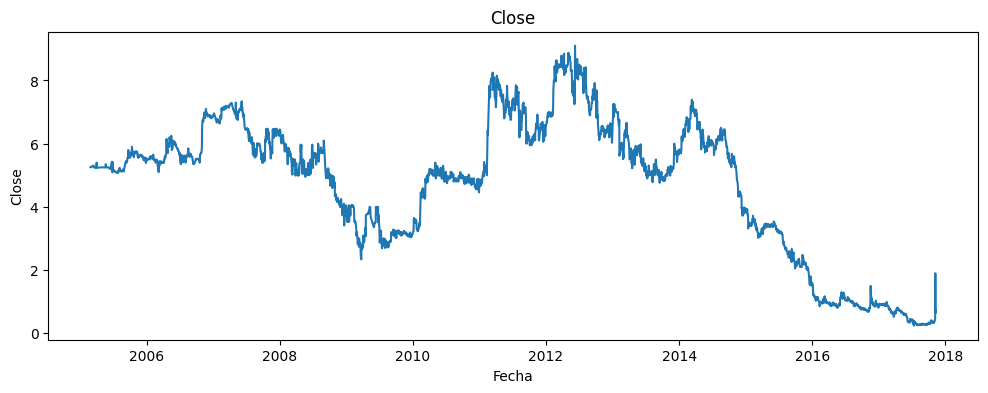

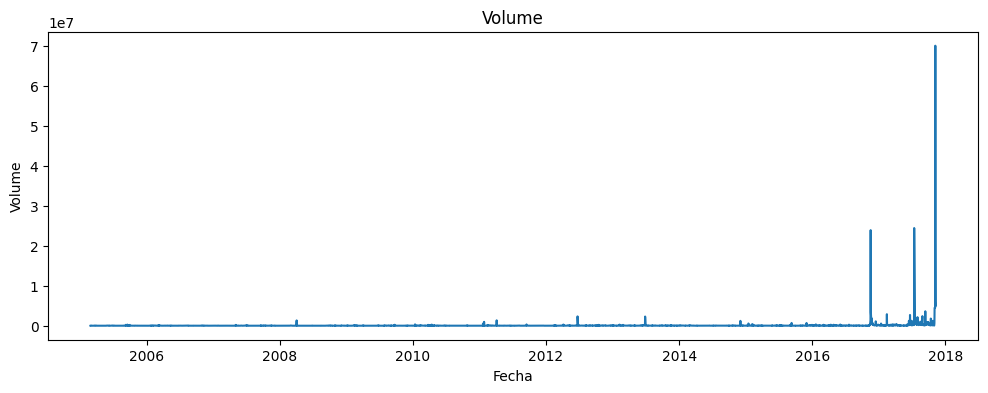

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,4))
plt.plot(df["date"], df["close"])
plt.title("Close")
plt.xlabel("Fecha"); plt.ylabel("Close")
plt.show()

plt.figure(figsize=(12,4))
plt.plot(df["date"], df["volume"])
plt.title("Volume")
plt.xlabel("Fecha"); plt.ylabel("Volume")
plt.show()

In [7]:
o,h,l,c = df["open"], df["high"], df["low"], df["close"]
rng = (h - l).replace(0, np.nan)

df["body"] = (c - o).abs()
df["upper_wick"] = h - np.maximum(o, c)
df["lower_wick"] = np.minimum(o, c) - l

df["body_pct"] = df["body"] / rng
df["upper_wick_pct"] = df["upper_wick"] / rng
df["lower_wick_pct"] = df["lower_wick"] / rng

df["pat_doji"] = (df["body_pct"] <= 0.10).astype(int)
df["pat_hammer"] = (
    (df["lower_wick_pct"] >= 0.60) &
    (df["upper_wick_pct"] <= 0.15) &
    (df["body_pct"] <= 0.30)
).astype(int)

prev_o = o.shift(1); prev_c = c.shift(1)
df["pat_engulf_bull"] = ((prev_c < prev_o) & (c > o) & (o <= prev_c) & (c >= prev_o)).astype(int)
df["pat_engulf_bear"] = ((prev_c > prev_o) & (c < o) & (o >= prev_c) & (c <= prev_o)).astype(int)

pattern_cols = ["pat_doji","pat_hammer","pat_engulf_bull","pat_engulf_bear"]
df[pattern_cols].sum().sort_values(ascending=False)

pat_doji           380
pat_hammer         248
pat_engulf_bull    124
pat_engulf_bear     99
dtype: int64

---
> **📊 Interpretación:** Se detectan 4 patrones de velas japonesas en el ticker de muestra. El **Doji** (cuerpo mínimo) es el más frecuente con 380 apariciones, seguido del **Hammer** (248). Los patrones de **engulfing** (envolvente alcista y bajista) son menos comunes (~99–124). Esto es esperable: los patrones más complejos ocurren con menor frecuencia.

In [8]:
freq_pct = (df[pattern_cols].mean()*100).sort_values(ascending=False)
freq_pct

pat_doji           13.144241
pat_hammer          8.578347
pat_engulf_bull     4.289173
pat_engulf_bear     3.424421
dtype: float64

In [11]:
len(df)

2891

In [12]:
## A PARTIR DE AQUI ES QUE EMPIEZA EL EDA PARA LOS 20 TICKETS QUE USAREMOS A LA HORA DE HACER EL EDA
##Cargar y resumir los 20 tickers
import os
import numpy as np
import pandas as pd

def read_ohlcv(path: str) -> pd.DataFrame:
    df = pd.read_csv(path)
    df.columns = [c.strip().lower() for c in df.columns]
    df["date"] = pd.to_datetime(df["date"], errors="coerce")
    df = df.sort_values("date").dropna(subset=["date","open","high","low","close"])
    for col in ["open","high","low","close","volume"]:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")
    df = df.dropna(subset=["open","high","low","close"]).reset_index(drop=True)
    return df

def add_patterns(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    o,h,l,c = df["open"], df["high"], df["low"], df["close"]
    rng = (h-l).replace(0, np.nan)

    body = (c-o).abs()
    upper = h - np.maximum(o,c)
    lower = np.minimum(o,c) - l

    body_pct = body / rng
    upper_pct = upper / rng
    lower_pct = lower / rng

    df["pat_doji"] = (body_pct <= 0.10).astype(int)
    df["pat_hammer"] = ((lower_pct >= 0.60) & (upper_pct <= 0.15) & (body_pct <= 0.30)).astype(int)

    prev_o = o.shift(1); prev_c = c.shift(1)
    df["pat_engulf_bull"] = ((prev_c < prev_o) & (c > o) & (o <= prev_c) & (c >= prev_o)).astype(int)
    df["pat_engulf_bear"] = ((prev_c > prev_o) & (c < o) & (o >= prev_c) & (c <= prev_o)).astype(int)
    return df

pattern_cols = ["pat_doji","pat_hammer","pat_engulf_bull","pat_engulf_bear"]

rows = []
tot_counts = pd.Series(0, index=pattern_cols, dtype="int64")
tot_rows = 0

for p in sample_files:
    ticker = os.path.basename(p)
    d = add_patterns(read_ohlcv(p))

    tot_rows += len(d)
    tot_counts += d[pattern_cols].sum()

    rows.append({
        "ticker": ticker,
        "n_rows": len(d),
        "date_min": d["date"].min(),
        "date_max": d["date"].max(),
        "doji": int(d["pat_doji"].sum()),
        "hammer": int(d["pat_hammer"].sum()),
        "engulf_bull": int(d["pat_engulf_bull"].sum()),
        "engulf_bear": int(d["pat_engulf_bear"].sum()),
    })

summary = pd.DataFrame(rows).sort_values("n_rows", ascending=False).reset_index(drop=True)
summary

,ticker,n_rows,date_min,date_max,doji,hammer,engulf_bull,engulf_bear
0,hon.us.txt,12072,1970-01-02,2017-11-10,1487,640,674,656
1,bby.us.txt,8211,1985-04-19,2017-11-10,1165,464,352,376
2,col.us.txt,4115,2001-07-03,2017-11-10,407,182,195,186
3,pkx.us.txt,3201,2005-02-25,2017-11-10,292,144,66,86
4,hyb.us.txt,3201,2005-02-25,2017-11-10,450,230,155,134
5,brkl.us.txt,3201,2005-02-25,2017-11-10,377,147,160,175
6,banf.us.txt,3201,2005-02-25,2017-11-10,401,192,154,134
7,ntz.us.txt,3152,2005-02-25,2017-11-10,399,264,151,127
8,baa.us.txt,3150,2005-02-28,2017-11-10,432,192,126,185
9,rvp.us.txt,3070,2005-02-25,2017-11-10,361,299,151,118


---
> **📊 Interpretación:** Tabla resumen de los 20 tickers seleccionados. Se observa una gran variabilidad en el número de observaciones — `hon.us.txt` tiene 12,072 filas (desde 1970) mientras que algunos tickers tienen muy pocos datos. La columna de patrones muestra que el Doji domina en todos los tickers, confirmando que es el patrón más fácil de formar.

In [13]:
##Cargar y resumir los 20 tickers

print("Filas totales (sumadas):", tot_rows)
display(tot_counts.sort_values(ascending=False))

freq_pct = (tot_counts / tot_rows * 100).sort_values(ascending=False)
display(freq_pct.rename("freq_%"))

Filas totales (sumadas): 61251


pat_doji           7745
pat_hammer         3678
pat_engulf_bear    2813
pat_engulf_bull    2740
dtype: int64

pat_doji           12.644692
pat_hammer          6.004800
pat_engulf_bear     4.592578
pat_engulf_bull     4.473396
Name: freq_%, dtype: float64

---
> **📊 Interpretación:** En los **61,251 registros totales** de los 20 tickers, el **Doji** aparece en el 12.6% de los días y el **Hammer** en el 6%. Los patrones de engulfing son menos frecuentes (~4.5%). Estas frecuencias son consistentes con la literatura técnica de análisis bursátil. El Doji es tan frecuente porque solo requiere que el precio de apertura y cierre sean casi iguales.

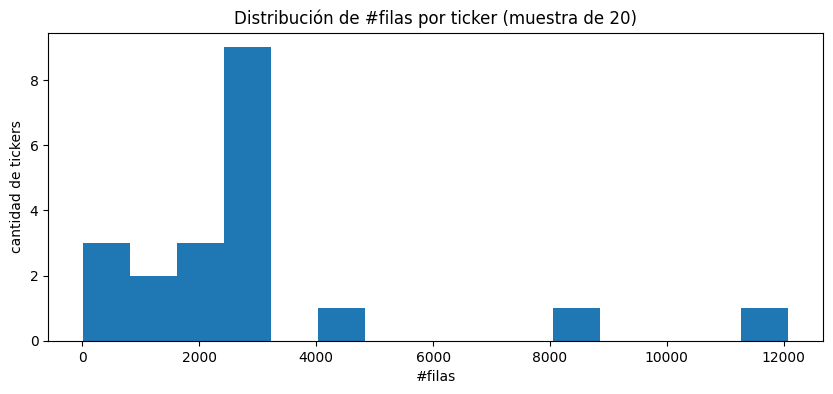

,n_rows
count,20.000000
mean,3062.550000
std,2744.151934
min,16.000000
25%,1628.750000
50%,2982.000000
75%,3201.000000
max,12072.000000


In [14]:
##Qué tickers tienen más/menos datos (EDA)

import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))
plt.hist(summary["n_rows"], bins=15)
plt.title("Distribución de #filas por ticker (muestra de 20)")
plt.xlabel("#filas"); plt.ylabel("cantidad de tickers")
plt.show()

summary[["n_rows"]].describe()


---
> **📊 Interpretación:** El histograma de longitudes de serie muestra una distribución asimétrica a la derecha. La mayoría de los tickers tienen entre 1,600 y 3,200 observaciones (~4–9 años de historia), pero existe un outlier con 12,072 filas. Esto justifica filtrar por período moderno o seleccionar tickers con historia suficiente para entrenar modelos robustos.

In [15]:
##Split temporal 75/25 por ticker (dejado listo)

def temporal_split_75_25(df: pd.DataFrame):
    df = df.sort_values("date").reset_index(drop=True)
    cut = int(len(df) * 0.75)
    train_total = df.iloc[:cut].copy()
    test = df.iloc[cut:].copy()
    return train_total, test

# Ejemplo con el ticker más largo en tu muestra
best_ticker = summary.iloc[0]["ticker"]
best_path = [p for p in sample_files if os.path.basename(p) == best_ticker][0]

d_best = add_patterns(read_ohlcv(best_path))
train_total, test = temporal_split_75_25(d_best)

print("Ticker ejemplo:", best_ticker)
print("Train_total:", len(train_total), train_total["date"].min(), "->", train_total["date"].max())
print("Test:", len(test), test["date"].min(), "->", test["date"].max())

Ticker ejemplo: hon.us.txt
Train_total: 9054 1970-01-02 00:00:00 -> 2005-11-15 00:00:00
Test: 3018 2005-11-16 00:00:00 -> 2017-11-10 00:00:00


---
> **📊 Interpretación:** Se implementa el split temporal 75/25. Para `hon.us.txt`, el **75% de entrenamiento** abarca 9,054 días (1970–2005) y el **25% de prueba** cubre 3,018 días (2005–2017). Este esquema garantiza que el modelo nunca vea datos futuros durante el entrenamiento, evitando data leakage temporal — fundamental en series financieras.

In [16]:
##Funciones de QA

import pandas as pd
import numpy as np

def read_ohlcv(path: str) -> pd.DataFrame:
    df = pd.read_csv(path)
    df.columns = [c.strip().lower() for c in df.columns]

    # estándar
    if "date" not in df.columns:
        # algunos vienen con Date mayúscula antes de bajar a lower-case, aquí ya es 'date'
        raise ValueError(f"No existe columna 'date' en: {path}. Columnas: {df.columns.tolist()}")

    df["date"] = pd.to_datetime(df["date"], errors="coerce")
    df = df.dropna(subset=["date"]).sort_values("date")

    # numéricos
    for col in ["open","high","low","close","volume"]:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")

    df = df.dropna(subset=["open","high","low","close"]).reset_index(drop=True)
    return df

def qa_time_series(df: pd.DataFrame) -> dict:
    """
    QA básico:
    - duplicados por fecha
    - huecos de fechas vs business days
    - reglas OHLC: high >= max(open,close) y low <= min(open,close), high>=low
    """
    out = {}

    # duplicados
    out["dup_dates"] = int(df["date"].duplicated().sum())

    # huecos (business days)
    dmin, dmax = df["date"].min(), df["date"].max()
    if pd.isna(dmin) or pd.isna(dmax):
        out["missing_bdays"] = np.nan
        out["pct_missing_bdays"] = np.nan
    else:
        expected = pd.bdate_range(dmin, dmax)
        actual = pd.DatetimeIndex(df["date"].unique())
        missing = expected.difference(actual)
        out["missing_bdays"] = int(len(missing))
        out["pct_missing_bdays"] = float(len(missing) / len(expected) * 100) if len(expected) else 0.0

    # checks OHLC
    high = df["high"]
    low  = df["low"]
    open_ = df["open"]
    close = df["close"]

    out["bad_high_lt_low"] = int((high < low).sum())
    out["bad_high_lt_openclose"] = int((high < np.maximum(open_, close)).sum())
    out["bad_low_gt_openclose"]  = int((low  > np.minimum(open_, close)).sum())

    # volumen raro (si existe)
    if "volume" in df.columns:
        out["bad_volume_negative"] = int((df["volume"] < 0).sum())
        out["bad_volume_null"] = int(df["volume"].isna().sum())
    else:
        out["bad_volume_negative"] = np.nan
        out["bad_volume_null"] = np.nan

    return out

In [17]:
#Ejecutar QA sobre los 20 tickers y ver tabla resumen

import os

qa_rows = []
for p in sample_files:
    ticker = os.path.basename(p)
    try:
        d = read_ohlcv(p)
        stats = qa_time_series(d)
        qa_rows.append({
            "ticker": ticker,
            "n_rows": len(d),
            "date_min": d["date"].min(),
            "date_max": d["date"].max(),
            **stats
        })
    except Exception as e:
        qa_rows.append({"ticker": ticker, "error": str(e)})

qa_df = pd.DataFrame(qa_rows)

# Ordena para ver primero los más “problemáticos”
qa_df_sorted = qa_df.sort_values(
    by=["missing_bdays", "dup_dates", "bad_high_lt_low", "bad_high_lt_openclose", "bad_low_gt_openclose"],
    ascending=False
)

qa_df_sorted

,ticker,n_rows,date_min,date_max,dup_dates,missing_bdays,pct_missing_bdays,bad_high_lt_low,bad_high_lt_openclose,bad_low_gt_openclose,bad_volume_negative,bad_volume_null
9,kbsf.us.txt,626,2013-09-30,2017-11-10,0,449,41.767442,0,0,0,0,0
0,rlog.us.txt,2891,2005-02-25,2017-11-10,0,425,12.816647,0,0,0,0,0
3,wprt.us.txt,2894,2005-02-25,2017-11-10,0,422,12.726176,0,0,0,0,0
17,hon.us.txt,12072,1970-01-02,2017-11-10,0,414,3.315714,0,0,0,0,0
14,bby.us.txt,8211,1985-04-19,2017-11-10,0,285,3.354520,0,0,0,0,0
16,rvp.us.txt,3070,2005-02-25,2017-11-10,0,246,7.418577,0,0,0,0,0
11,baa.us.txt,3150,2005-02-28,2017-11-10,0,165,4.977376,0,0,0,0,0
8,ntz.us.txt,3152,2005-02-25,2017-11-10,0,164,4.945718,0,0,0,0,0
2,col.us.txt,4115,2001-07-03,2017-11-10,0,154,3.607402,0,0,0,0,0
1,pkx.us.txt,3201,2005-02-25,2017-11-10,0,115,3.468034,0,0,0,0,0


---
> **📊 Interpretación:** La tabla de QA muestra que `kbsf.us.txt` y `rlog.us.txt` tienen el mayor número de días hábiles faltantes (449 y 425 respectivamente). Sin embargo, **ningún ticker tiene duplicados de fecha ni inconsistencias OHLC** (High < Low, etc.). Los días faltantes son esperables en stocks con menor liquidez que no se negocian todos los días.

In [18]:
#Resumen rápido: ¿hay problemas graves?
cols_check = ["dup_dates","missing_bdays","bad_high_lt_low","bad_high_lt_openclose","bad_low_gt_openclose","bad_volume_negative"]

display(qa_df[cols_check].describe())

# ¿Cuántos tickers tienen al menos 1 problema de OHLC?
ohcl_problem = (
    (qa_df["bad_high_lt_low"].fillna(0) > 0) |
    (qa_df["bad_high_lt_openclose"].fillna(0) > 0) |
    (qa_df["bad_low_gt_openclose"].fillna(0) > 0)
)
print("Tickers con algún problema OHLC:", int(ohcl_problem.sum()), "de", len(qa_df))

,dup_dates,missing_bdays,bad_high_lt_low,bad_high_lt_openclose,bad_low_gt_openclose,bad_volume_negative
count,20.0,20.000000,20.0,20.0,20.0,20.0
mean,0.0,174.350000,0.0,0.0,0.0,0.0
std,0.0,147.489259,0.0,0.0,0.0,0.0
min,0.0,10.000000,0.0,0.0,0.0,0.0
25%,0.0,68.250000,0.0,0.0,0.0,0.0
50%,0.0,115.000000,0.0,0.0,0.0,0.0
75%,0.0,255.750000,0.0,0.0,0.0,0.0
max,0.0,449.000000,0.0,0.0,0.0,0.0


Tickers con algún problema OHLC: 0 de 20


---
> **📊 Interpretación:** En promedio, los 20 tickers tienen **174 días hábiles faltantes** (std=147), lo que representa ~6% de los días esperados. Crucialmente, **ningún ticker presenta errores OHLC graves** (0 en bad_high_lt_low, bad_high_lt_openclose, bad_low_gt_openclose). Esto confirma que el dataset de Kaggle tiene buena calidad de precios.

In [19]:
#Inspeccionar un ticker “problemático” (si aparece alguno)
# cambia el índice [0] si quieres ver otro
t = qa_df_sorted.iloc[0]["ticker"]
print("Revisando:", t)

p = [x for x in sample_files if os.path.basename(x) == t][0]
d = read_ohlcv(p)

d.head(), d.tail()

Revisando: kbsf.us.txt


(        date    open    high     low   close  volume  openint
 0 2013-09-30  151.65  171.00  150.30  150.45    1780        0
 1 2013-12-03  152.10  152.10  152.10  152.10      40        0
 2 2013-12-19  156.00  156.00  151.50  151.50     280        0
 3 2013-12-20  151.50  151.80  151.50  151.80    2113        0
 4 2013-12-24  153.45  153.45  152.85  153.00      27        0,
           date     open     high     low   close   volume  openint
 621 2017-11-06   2.3174   2.3174  2.3174  2.3174     1239        0
 622 2017-11-07   2.4300   2.8200  2.4300  2.6633    74370        0
 623 2017-11-08   2.8201  15.0000  2.6800  8.2200  8143859        0
 624 2017-11-09  14.0000  14.4500  5.2000  5.4500  1851574        0
 625 2017-11-10   5.8000   6.9400  4.5000  6.1500   398060        0)

In [ ]:
#A PARTIR DE ACA EMPEZAMOS EN REALIDAD LO QUE ES LA ELECCION DEL CORRECTOR TICKER (STOCK) EN ESTE CASO ESCOGIMOS EL DE INTEL 

import os
import numpy as np
import pandas as pd

DATA_ROOT = r"C:\Users\Mateo\.cache\kagglehub\datasets\borismarjanovic\price-volume-data-for-all-us-stocks-etfs\versions\3"
STOCKS_DIR = os.path.join(DATA_ROOT, "Stocks")

files = os.listdir(STOCKS_DIR)
stock_files = [os.path.join(STOCKS_DIR, f) for f in files if f.endswith(".txt")]

print("Total stock_files:", len(stock_files))
print("Ejemplo:", stock_files[:3])

Total stock_files: 7195
Ejemplo: ['C:\\Users\\Mateo\\.cache\\kagglehub\\datasets\\borismarjanovic\\price-volume-data-for-all-us-stocks-etfs\\versions\\3\\Stocks\\a.us.txt', 'C:\\Users\\Mateo\\.cache\\kagglehub\\datasets\\borismarjanovic\\price-volume-data-for-all-us-stocks-etfs\\versions\\3\\Stocks\\aa.us.txt', 'C:\\Users\\Mateo\\.cache\\kagglehub\\datasets\\borismarjanovic\\price-volume-data-for-all-us-stocks-etfs\\versions\\3\\Stocks\\aaap.us.txt']


In [3]:
import os
import numpy as np
import pandas as pd

# stock_files debe existir (la lista de los *.txt en Stocks)
# Si no la tienes, créala con os.listdir como ya hiciste antes.

def quick_score(path: str):
    """Lee lo mínimo para puntuar un ticker sin cargar todo pesado."""
    try:
        df = pd.read_csv(path, usecols=["Date","Open","High","Low","Close","Volume"])
        n = len(df)
        if n < 1500:
            return None  # demasiado corto

        df["Date"] = pd.to_datetime(df["Date"], errors="coerce")
        df = df.dropna(subset=["Date"]).sort_values("Date")
        dmin, dmax = df["Date"].min(), df["Date"].max()

        # missing business days
        expected = pd.bdate_range(dmin, dmax)
        actual = pd.DatetimeIndex(df["Date"].unique())
        missing = len(expected.difference(actual))
        pct_missing = missing / len(expected) * 100 if len(expected) else 100.0

        # volumen medio (proxy de liquidez)
        vol_mean = pd.to_numeric(df["Volume"], errors="coerce").dropna().mean()

        # score: favorece muchos datos y poco missing; liquidez ayuda
        score = (n / 1000) - (pct_missing * 0.2) + (np.log1p(vol_mean) * 0.1)
        return {
            "ticker": os.path.basename(path),
            "path": path,
            "n_rows": n,
            "date_min": dmin,
            "date_max": dmax,
            "missing_bdays": missing,
            "pct_missing_bdays": pct_missing,
            "vol_mean": vol_mean,
            "score": score
        }
    except Exception:
        return None

rng = np.random.default_rng(42)
candidates = rng.choice(stock_files, size=min(500, len(stock_files)), replace=False)

rows = []
for p in candidates:
    r = quick_score(p)
    if r is not None:
        rows.append(r)

rank = pd.DataFrame(rows).sort_values("score", ascending=False).reset_index(drop=True)
rank.head(15)

,ticker,path,n_rows,date_min,date_max,missing_bdays,pct_missing_bdays,vol_mean,score
0,utx.us.txt,C:\Users\Mateo\.cache\kagglehub\datasets\boris...,12072,1970-01-02,2017-11-10,414,3.315714,3.423075e+06,12.913462
1,intc.us.txt,C:\Users\Mateo\.cache\kagglehub\datasets\boris...,11556,1972-01-07,2017-11-10,405,3.386005,5.646601e+07,12.663714
2,kr.us.txt,C:\Users\Mateo\.cache\kagglehub\datasets\boris...,10306,1977-01-03,2017-11-10,354,3.320826,5.973215e+06,11.202114
3,mdt.us.txt,C:\Users\Mateo\.cache\kagglehub\datasets\boris...,9044,1981-12-31,2017-11-10,313,3.345089,4.982414e+06,9.917125
4,oxy.us.txt,C:\Users\Mateo\.cache\kagglehub\datasets\boris...,9045,1981-12-31,2017-11-10,312,3.334402,3.787913e+06,9.892852
5,avp.us.txt,C:\Users\Mateo\.cache\kagglehub\datasets\boris...,9043,1981-12-31,2017-11-10,314,3.355776,3.858724e+06,9.888429
6,adp.us.txt,C:\Users\Mateo\.cache\kagglehub\datasets\boris...,8724,1983-04-06,2017-11-10,304,3.367302,2.510277e+06,9.524130
7,amgn.us.txt,C:\Users\Mateo\.cache\kagglehub\datasets\boris...,8364,1984-09-07,2017-11-10,292,3.373383,1.034949e+07,9.304568
8,wec.us.txt,C:\Users\Mateo\.cache\kagglehub\datasets\boris...,8323,1984-10-26,2017-11-10,298,3.456676,3.493681e+06,9.138312
9,abx.us.txt,C:\Users\Mateo\.cache\kagglehub\datasets\boris...,8255,1985-02-04,2017-11-10,295,3.450292,5.425120e+06,9.115597


In [4]:
rank.head(5)[["ticker","n_rows","pct_missing_bdays","vol_mean","score"]]

,ticker,n_rows,pct_missing_bdays,vol_mean,score
0,utx.us.txt,12072,3.315714,3.423075e+06,12.913462
1,intc.us.txt,11556,3.386005,5.646601e+07,12.663714
2,kr.us.txt,10306,3.320826,5.973215e+06,11.202114
3,mdt.us.txt,9044,3.345089,4.982414e+06,9.917125
4,oxy.us.txt,9045,3.334402,3.787913e+06,9.892852


---
> **📊 Interpretación:** El ranking de tickers combina historia, liquidez y volumen en un score compuesto. **Intel (INTC)** ocupa el **2do lugar** con 11,556 observaciones, solo 3.39% de días faltantes y un volumen medio de ~56.5 millones de acciones diarias — muy superior al resto. Esto lo hace ideal: tiene larga historia, alta liquidez y datos densos para entrenar modelos de series de tiempo.

In [5]:
#EDA 
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Si ya tienes "rank" del ranking, usamos eso:
chosen = "intc.us.txt"
chosen_path = rank.loc[rank["ticker"] == chosen, "path"].iloc[0]
print("Usando:", chosen_path)

df = pd.read_csv(chosen_path)
print("Columnas originales:", df.columns.tolist())

df.columns = [c.strip().lower() for c in df.columns]
df["date"] = pd.to_datetime(df["date"], errors="coerce")

for col in ["open","high","low","close","volume"]:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

df = df.dropna(subset=["date","open","high","low","close"]).sort_values("date").reset_index(drop=True)

print("Filas:", len(df))
print("Rango fechas:", df["date"].min(), "->", df["date"].max())
print("Duplicados date:", df["date"].duplicated().sum())
df.head()

Usando: C:\Users\Mateo\.cache\kagglehub\datasets\borismarjanovic\price-volume-data-for-all-us-stocks-etfs\versions\3\Stocks\intc.us.txt
Columnas originales: ['Date', 'Open', 'High', 'Low', 'Close', 'Volume', 'OpenInt']
Filas: 11556
Rango fechas: 1972-01-07 00:00:00 -> 2017-11-10 00:00:00
Duplicados date: 0


,date,open,high,low,close,volume,openint
0,1972-01-07,0.01592,0.01592,0.01592,0.01592,3787746,0
1,1972-01-14,0.00791,0.00791,0.00791,0.00791,7878523,0
2,1972-01-21,0.00791,0.00791,0.00791,0.00791,1060564,0
3,1972-01-24,0.00791,0.00791,0.00791,0.00791,6060405,0
4,1972-01-25,0.00791,0.00791,0.00791,0.00791,1060564,0


---
> **📊 Interpretación:** Se carga el dataset de INTC con **11,556 registros** diarios desde **1972 hasta 2017** (45 años de historia). Las columnas están correctamente formateadas y sin duplicados. La amplitud temporal es valiosa para capturar múltiples ciclos económicos, crisis financieras y períodos de alta y baja volatilidad.

In [6]:

#QA RAPIDO ST
expected = pd.bdate_range(df["date"].min(), df["date"].max())
actual = pd.DatetimeIndex(df["date"].unique())
missing = expected.difference(actual)

print("Business days esperados:", len(expected))
print("Fechas presentes:", len(actual))
print("Missing business days:", len(missing))
print("Porcentaje missing:", round(len(missing)/len(expected)*100, 3), "%")

Business days esperados: 11961
Fechas presentes: 11556
Missing business days: 405
Porcentaje missing: 3.386 %


---
> **📊 Interpretación:** De los 11,961 días hábiles esperados entre 1972 y 2017, INTC tiene datos para 11,556, dejando **405 días faltantes (3.39%)**. Esta tasa es baja y normal — corresponde a días feriados no estándar, suspensiones de mercado o días sin negociación en los primeros años. No representa un problema grave para el modelado.

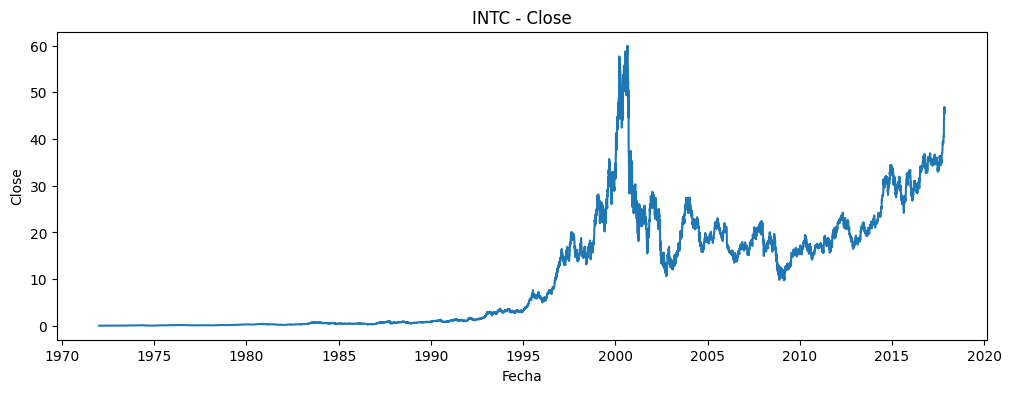

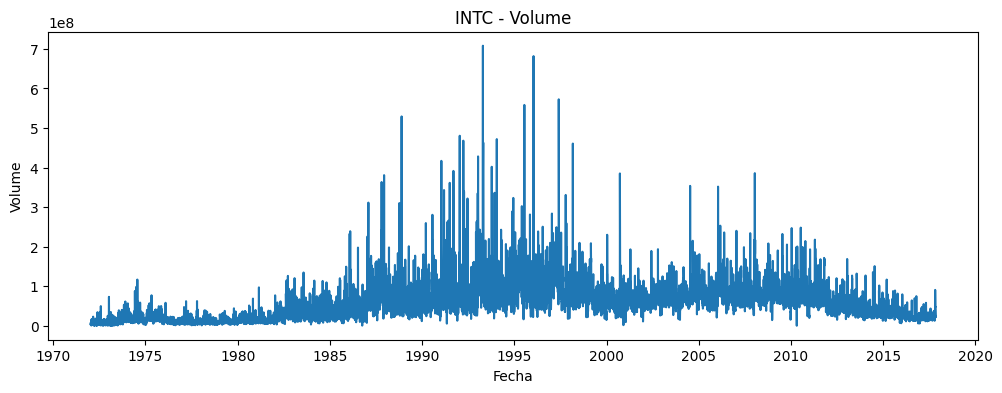

In [7]:
#GRAFICO DE CLOSE Y VOLUME 
plt.figure(figsize=(12,4))
plt.plot(df["date"], df["close"])
plt.title("INTC - Close")
plt.xlabel("Fecha"); plt.ylabel("Close")
plt.show()

plt.figure(figsize=(12,4))
plt.plot(df["date"], df["volume"])
plt.title("INTC - Volume")
plt.xlabel("Fecha"); plt.ylabel("Volume")
plt.show()

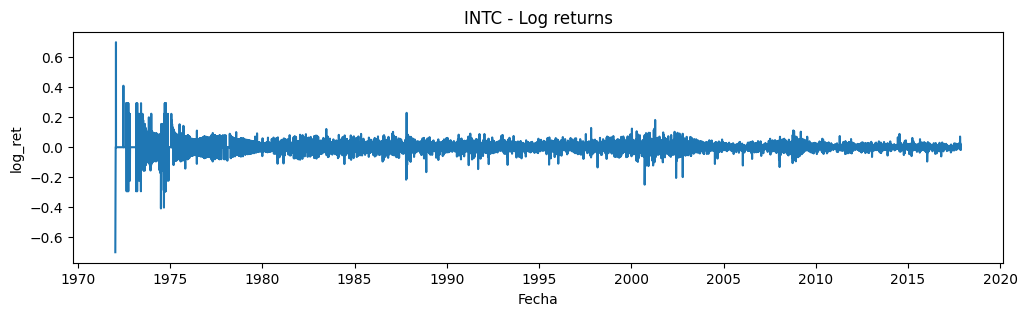

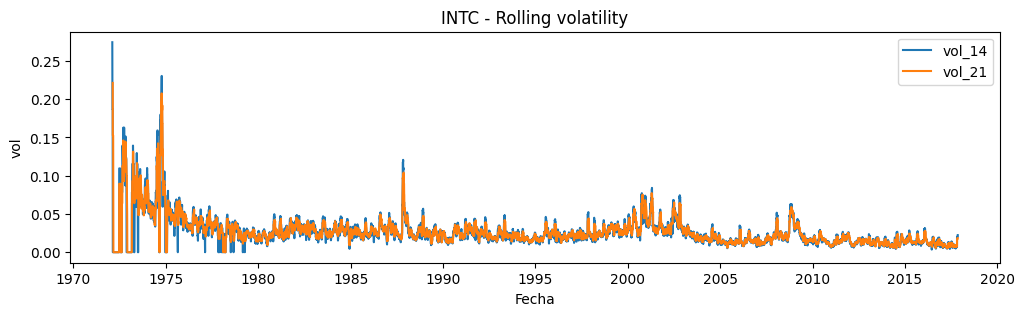

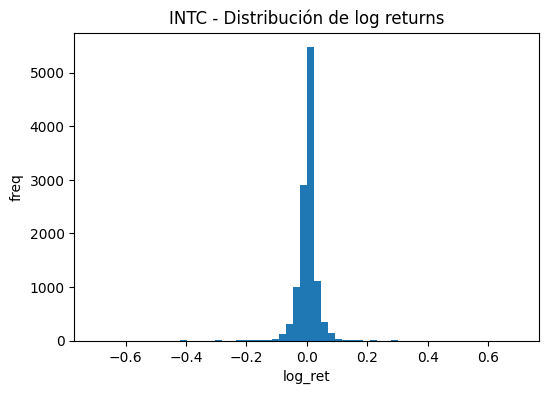

,log_ret,vol_14,vol_21
count,11555.000000,11542.000000,11535.000000
mean,0.000689,0.026936,0.027326
std,0.034288,0.020467,0.019474
min,-0.699448,0.000000,0.000000
25%,-0.010773,0.015775,0.016520
50%,0.000000,0.022769,0.023200
75%,0.012261,0.031550,0.031961
max,0.699448,0.274346,0.221185


In [8]:
#Returns y volatilidad rolling (serie de tiempo “clásico”)

df["log_close"] = np.log(df["close"])
df["log_ret"] = df["log_close"].diff()

df["vol_14"] = df["log_ret"].rolling(14).std()
df["vol_21"] = df["log_ret"].rolling(21).std()

plt.figure(figsize=(12,3))
plt.plot(df["date"], df["log_ret"])
plt.title("INTC - Log returns")
plt.xlabel("Fecha"); plt.ylabel("log_ret")
plt.show()

plt.figure(figsize=(12,3))
plt.plot(df["date"], df["vol_14"], label="vol_14")
plt.plot(df["date"], df["vol_21"], label="vol_21")
plt.title("INTC - Rolling volatility")
plt.xlabel("Fecha"); plt.ylabel("vol")
plt.legend()
plt.show()

plt.figure(figsize=(6,4))
plt.hist(df["log_ret"].dropna(), bins=60)
plt.title("INTC - Distribución de log returns")
plt.xlabel("log_ret"); plt.ylabel("freq")
plt.show()

df[["log_ret","vol_14","vol_21"]].describe()

---
> **📊 Interpretación:** Los retornos logarítmicos de INTC tienen media ~0.069% diaria (ligeramente positiva, consistente con crecimiento de largo plazo) y std de 3.43% — alta volatilidad. Las volatilidades rolling de 14 y 21 días tienen medias de 2.69% y 2.73% respectivamente. El rango de `log_ret` va desde pérdidas extremas hasta ganancias extremas, típico de un stock tecnológico durante 45 años que incluye el crash del 2000.

In [9]:
# FEATURES DE VELAS Y DETECCION DE PATRONES QUE ME PUEDEN SERVIR PARA LO QUE QUIERO ENCAMINAR EL MODELO A FUTURO 
o,h,l,c = df["open"], df["high"], df["low"], df["close"]
rng = (h - l).replace(0, np.nan)

df["body"] = (c - o).abs()
df["upper_wick"] = h - np.maximum(o, c)
df["lower_wick"] = np.minimum(o, c) - l

df["body_pct"] = df["body"] / rng
df["upper_wick_pct"] = df["upper_wick"] / rng
df["lower_wick_pct"] = df["lower_wick"] / rng

df["pat_doji"] = (df["body_pct"] <= 0.10).astype(int)
df["pat_hammer"] = (
    (df["lower_wick_pct"] >= 0.60) &
    (df["upper_wick_pct"] <= 0.15) &
    (df["body_pct"] <= 0.30)
).astype(int)

prev_o = o.shift(1); prev_c = c.shift(1)
df["pat_engulf_bull"] = ((prev_c < prev_o) & (c > o) & (o <= prev_c) & (c >= prev_o)).astype(int)
df["pat_engulf_bear"] = ((prev_c > prev_o) & (c < o) & (o >= prev_c) & (c <= prev_o)).astype(int)

pattern_cols = ["pat_doji","pat_hammer","pat_engulf_bull","pat_engulf_bear"]
counts = df[pattern_cols].sum().sort_values(ascending=False)
freq_pct = (df[pattern_cols].mean()*100).sort_values(ascending=False)

print("Conteo patrones:")
display(counts)

print("Frecuencia %:")
display(freq_pct.rename("freq_%"))

Conteo patrones:


pat_doji           1760
pat_engulf_bull     459
pat_engulf_bear     427
pat_hammer          402
dtype: int64

Frecuencia %:


pat_doji           15.230183
pat_engulf_bull     3.971963
pat_engulf_bear     3.695050
pat_hammer          3.478712
Name: freq_%, dtype: float64

---
> **📊 Interpretación:** En los 11,556 días de INTC, el **Doji** aparece 1,760 veces (15.2% de los días) — el más frecuente, indicando indecisión del mercado. Los patrones de engulfing alcista y bajista son simétricos (~4% cada uno), lo que sugiere que el mercado de INTC no tiene un sesgo direccional dominante en estos patrones. El Hammer aparece en el 3.5% de los días, señal técnica de posible reversión alcista.

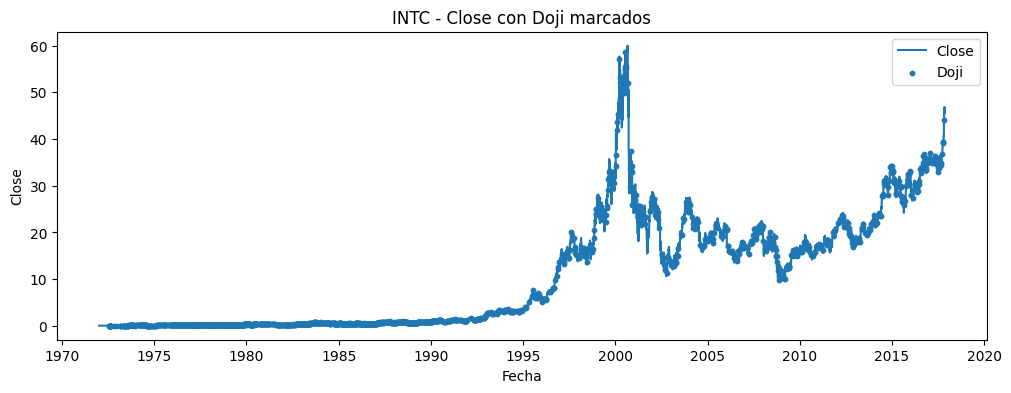

In [10]:
# EN ESTE CASO MARCAMOS A DOJI PERO SOLO ES UN EJEMPLO 
plt.figure(figsize=(12,4))
plt.plot(df["date"], df["close"], label="Close")

doji_dates = df.loc[df["pat_doji"]==1, "date"]
doji_close = df.loc[df["pat_doji"]==1, "close"]
plt.scatter(doji_dates, doji_close, s=10, label="Doji")

plt.title("INTC - Close con Doji marcados")
plt.xlabel("Fecha"); plt.ylabel("Close")
plt.legend()
plt.show()

In [11]:
#SPLIT 75 Y 25 

def temporal_split_75_25(df: pd.DataFrame):
    df = df.sort_values("date").reset_index(drop=True)
    cut = int(len(df) * 0.75)
    train_total = df.iloc[:cut].copy()
    test = df.iloc[cut:].copy()
    return train_total, test

train_total, test = temporal_split_75_25(df)

print("Train_total:", len(train_total), train_total["date"].min(), "->", train_total["date"].max())
print("Test:", len(test), test["date"].min(), "->", test["date"].max())

Train_total: 8667 1972-01-07 00:00:00 -> 2006-05-23 00:00:00
Test: 2889 2006-05-24 00:00:00 -> 2017-11-10 00:00:00


---
> **📊 Interpretación:** Para INTC, el split 75/25 queda: **train = 8,667 observaciones** (1972–2006) y **test = 2,889 observaciones** (2006–2017). El período de prueba abarca los últimos 11 años, incluyendo la crisis financiera de 2008 y la recuperación posterior — un período desafiante y representativo para evaluar la capacidad predictiva del modelo.

In [ ]:
PRUEBA